# Spatial Econometric Housing Diagnostics

This case mirrors PySAL spatial econometrics examples: contiguity weights, spatial autocorrelation, OLS residual diagnostics, spatial lag/error models, local clusters, and exportable diagnostics.

In [1]:
from pathlib import Path
import os, warnings
os.environ.setdefault("PROJ_LIB", "/opt/conda/share/proj")
os.environ.setdefault("PROJ_DATA", "/opt/conda/share/proj")
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from libpysal.weights import Queen
from esda.moran import Moran, Moran_Local
from spreg import ML_Lag, ML_Error
from IPython.display import display, Markdown
PROJECT = Path.cwd()
DATA = PROJECT / "data"
OUTPUTS = PROJECT / "outputs"
OUTPUTS.mkdir(exist_ok=True)
print("Ready. Data files:", [p.name for p in sorted(DATA.iterdir())])

Ready. Data files: ['housing_zones.geojson']


In [2]:
gdf = gpd.read_file(DATA / "housing_zones.geojson")
display(gdf.head())
display(gdf.drop(columns="geometry").describe().round(3))

,zone_id,income,transit,green,old_building,price,geometry
0,H001,10.074231,0.000000,0.394838,0.731375,6.558532,"POLYGON ((118.5 31.8, 118.525 31.8, 118.525 31..."
1,H002,10.852418,0.039310,0.473619,0.470030,6.920594,"POLYGON ((118.525 31.8, 118.55 31.8, 118.55 31..."
2,H003,9.600844,0.127419,0.676307,0.492118,6.283129,"POLYGON ((118.55 31.8, 118.575 31.8, 118.575 3..."
3,H004,11.357241,0.305815,0.731161,0.443765,7.234932,"POLYGON ((118.575 31.8, 118.6 31.8, 118.6 31.8..."
4,H005,10.718511,0.439536,0.801877,0.425135,6.953944,"POLYGON ((118.6 31.8, 118.625 31.8, 118.625 31..."


,income,transit,green,old_building,price
count,120.000,120.000,120.000,120.000,120.000
mean,10.931,0.395,0.447,0.473,7.152
std,0.712,0.234,0.279,0.177,0.498
min,9.344,0.000,0.020,0.050,6.187
25%,10.450,0.226,0.211,0.346,6.790
50%,10.890,0.382,0.464,0.457,7.111
75%,11.371,0.548,0.677,0.562,7.541
max,12.681,0.983,0.878,0.865,8.348


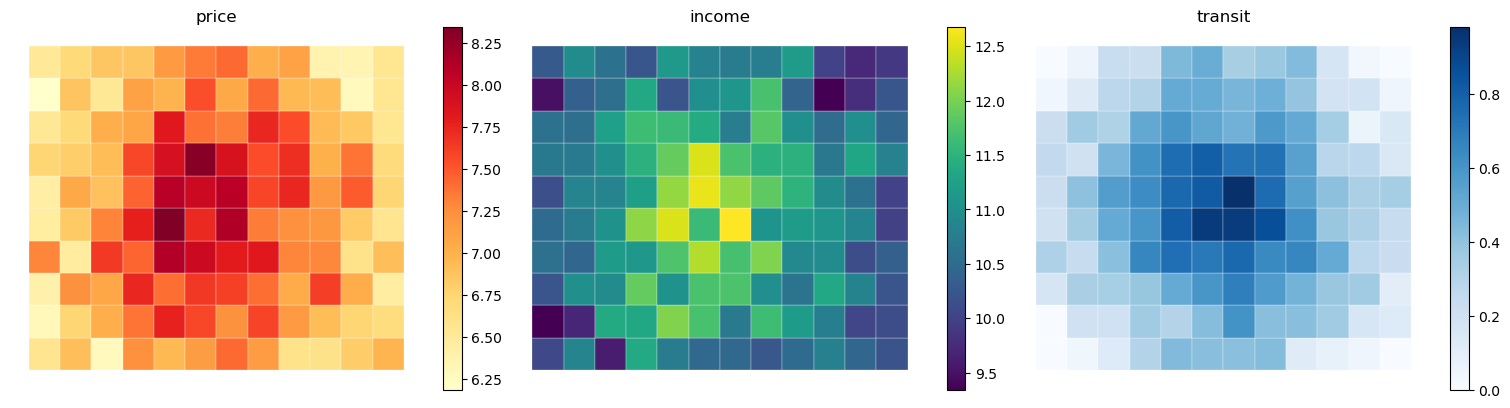

Saved outputs/housing_variable_maps.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, column, cmap in zip(axes, ["price", "income", "transit"], ["YlOrRd", "viridis", "Blues"]):
    gdf.plot(column=column, ax=ax, cmap=cmap, legend=True, edgecolor="white", linewidth=0.2)
    ax.set_title(column)
    ax.set_axis_off()
fig.savefig(OUTPUTS / "housing_variable_maps.png", dpi=170)
plt.show()
print("Saved outputs/housing_variable_maps.png")

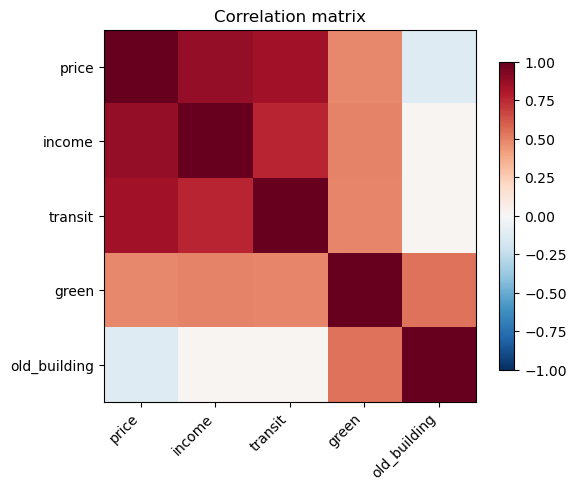

,price,income,transit,green,old_building
price,1.000,0.876,0.838,0.481,-0.133
income,0.876,1.000,0.763,0.495,0.019
transit,0.838,0.763,1.000,0.491,0.019
green,0.481,0.495,0.491,1.000,0.545
old_building,-0.133,0.019,0.019,0.545,1.000


In [4]:
corr = gdf[["price", "income", "transit", "green", "old_building"]].corr()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.index)), corr.index)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Correlation matrix")
fig.savefig(OUTPUTS / "housing_correlation_matrix.png", dpi=170)
plt.show()
display(corr.round(3))

In [5]:
w = Queen.from_dataframe(gdf, ids=gdf["zone_id"].tolist())
w.transform = "r"
neighbor_counts = pd.Series({k: len(v) for k, v in w.neighbors.items()}, name="neighbors")
print(f"Weights observations={w.n}, islands={w.islands}")
display(neighbor_counts.describe().round(2))
display(neighbor_counts.sort_values().head())

Weights observations=120, islands=[]


count    120.00
mean       6.93
std        1.55
min        3.00
25%        5.00
50%        8.00
75%        8.00
max        8.00
Name: neighbors, dtype: float64

H001    3
H012    3
H109    3
H120    3
H005    5
Name: neighbors, dtype: int64

In [6]:
m_price = Moran(gdf["price"].values, w, permutations=199)
print(f"Global Moran I for price: I={m_price.I:.3f}, p_sim={m_price.p_sim:.4f}")
local = Moran_Local(gdf["price"].values, w, permutations=199)
gdf["local_q"] = local.q
gdf["local_p"] = local.p_sim
gdf["local_cluster"] = np.where(gdf["local_p"] <= 0.05, gdf["local_q"].map({1:"HH",2:"LH",3:"LL",4:"HL"}), "Not significant")
display(gdf[["zone_id", "price", "local_cluster", "local_p"]].sort_values("local_p").head(10).round(3))

Global Moran I for price: I=0.643, p_sim=0.0050


,zone_id,price,local_cluster,local_p
1,H002,6.921,LL,0.005
28,H029,7.398,HH,0.005
29,H030,7.653,HH,0.005
52,H053,8.348,HH,0.005
40,H041,8.124,HH,0.005
41,H042,7.974,HH,0.005
42,H043,7.801,HH,0.005
55,H056,7.342,HH,0.005
51,H052,7.780,HH,0.005
54,H055,8.133,HH,0.005


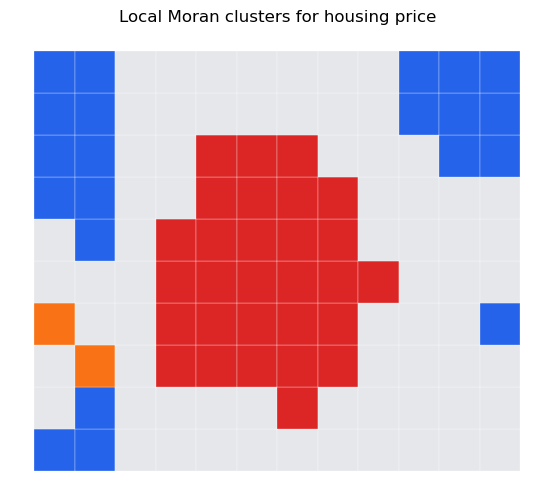

,count
local_cluster,
Not significant,68
HH,29
LL,21
HL,2


In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
colors = {"HH":"#dc2626", "LL":"#2563eb", "HL":"#f97316", "LH":"#22c55e", "Not significant":"#e5e7eb"}
gdf.assign(color=gdf["local_cluster"].map(colors)).plot(color=gdf["local_cluster"].map(colors), ax=ax, edgecolor="white", linewidth=0.2)
ax.set_title("Local Moran clusters for housing price")
ax.set_axis_off()
fig.savefig(OUTPUTS / "local_moran_price_clusters.png", dpi=170)
plt.show()
display(gdf["local_cluster"].value_counts().to_frame("count"))

In [8]:
y = gdf["price"].values
X = gdf[["income", "transit", "green", "old_building"]]
ols = sm.OLS(y, sm.add_constant(X)).fit()
gdf["ols_residual"] = ols.resid
print(ols.summary().tables[1])
print(f"OLS adjusted R2={ols.rsquared_adj:.3f}, AIC={ols.aic:.1f}")

                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            3.1052      0.380      8.174      0.000       2.353       3.858
income           0.3597      0.037      9.691      0.000       0.286       0.433
transit          0.7614      0.112      6.786      0.000       0.539       0.984
green            0.3336      0.089      3.747      0.000       0.157       0.510
old_building    -0.7074      0.120     -5.903      0.000      -0.945      -0.470
OLS adjusted R2=0.870, AIC=-66.6


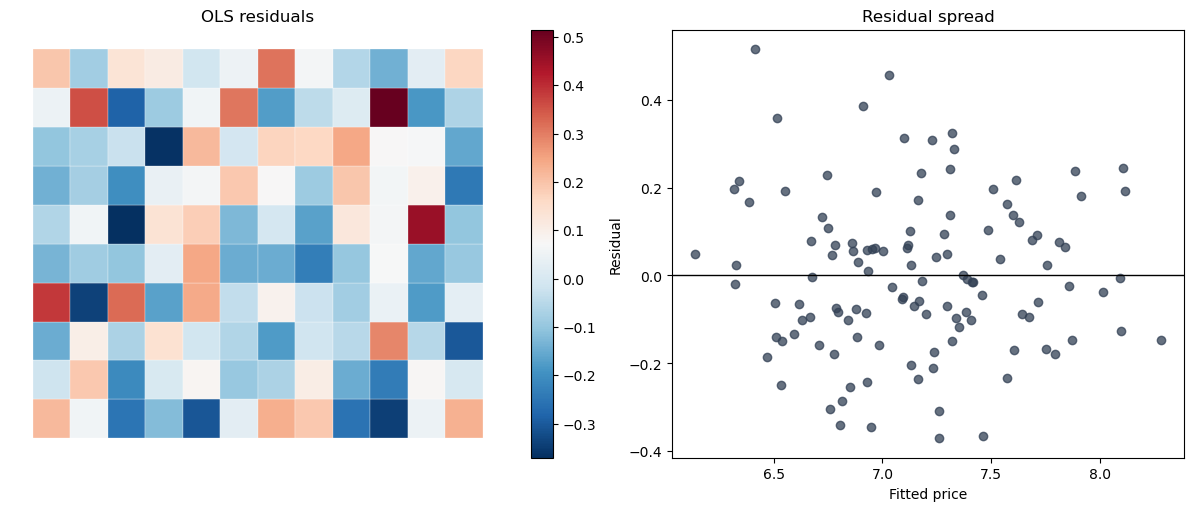

Residual Moran I=0.034, p_sim=0.2050


In [9]:
m_resid = Moran(gdf["ols_residual"].values, w, permutations=199)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
gdf.plot(column="ols_residual", ax=axes[0], cmap="RdBu_r", legend=True, edgecolor="white", linewidth=0.2)
axes[0].set_title("OLS residuals")
axes[0].set_axis_off()
axes[1].scatter(ols.fittedvalues, ols.resid, color="#334155", alpha=0.75)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_xlabel("Fitted price")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residual spread")
fig.savefig(OUTPUTS / "ols_residual_diagnostics.png", dpi=170)
plt.show()
print(f"Residual Moran I={m_resid.I:.3f}, p_sim={m_resid.p_sim:.4f}")

In [10]:
y2 = gdf[["price"]].values
X2 = gdf[["income", "transit", "green", "old_building"]].values
lag_model = ML_Lag(y2, X2, w=w, name_y="price", name_x=["income", "transit", "green", "old_building"])
err_model = ML_Error(y2, X2, w=w, name_y="price", name_x=["income", "transit", "green", "old_building"])
comparison = pd.DataFrame([
    {"model": "OLS", "aic": ols.aic, "pseudo_r2": ols.rsquared, "spatial_parameter": np.nan},
    {"model": "Spatial lag", "aic": lag_model.aic, "pseudo_r2": lag_model.pr2, "spatial_parameter": float(lag_model.rho)},
    {"model": "Spatial error", "aic": err_model.aic, "pseudo_r2": err_model.pr2, "spatial_parameter": float(err_model.lam)},
])
display(comparison.round(3))
comparison.to_csv(OUTPUTS / "spatial_model_comparison.csv", index=False)

ML_Lag
ML_Error


,model,aic,pseudo_r2,spatial_parameter
0,OLS,-66.648,0.874,NaN
1,Spatial lag,-64.674,0.874,-0.017
2,Spatial error,-67.168,0.874,0.126


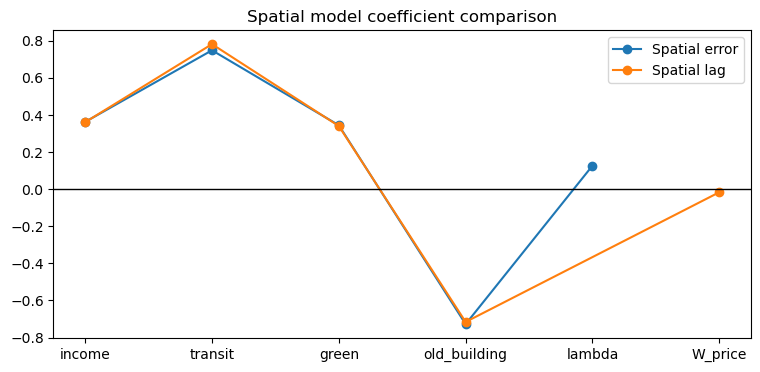

,model,term,coef
0,Spatial lag,CONSTANT,3.211
1,Spatial lag,income,0.360
2,Spatial lag,transit,0.781
3,Spatial lag,green,0.340
4,Spatial lag,old_building,-0.716
5,Spatial lag,W_price,-0.017
6,Spatial error,CONSTANT,3.089
7,Spatial error,income,0.362
8,Spatial error,transit,0.748
9,Spatial error,green,0.344


In [11]:
coef_rows = []
for label, model in [("Spatial lag", lag_model), ("Spatial error", err_model)]:
    names = list(model.name_x)
    for name, beta in zip(names, model.betas.flatten()):
        coef_rows.append({"model": label, "term": name, "coef": float(beta)})
coef_table = pd.DataFrame(coef_rows)
fig, ax = plt.subplots(figsize=(9, 4))
for model_name, sub in coef_table[coef_table["term"] != "CONSTANT"].groupby("model"):
    ax.plot(sub["term"], sub["coef"], marker="o", label=model_name)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Spatial model coefficient comparison")
ax.legend()
fig.savefig(OUTPUTS / "spatial_model_coefficients.png", dpi=170)
plt.show()
display(coef_table.round(3))

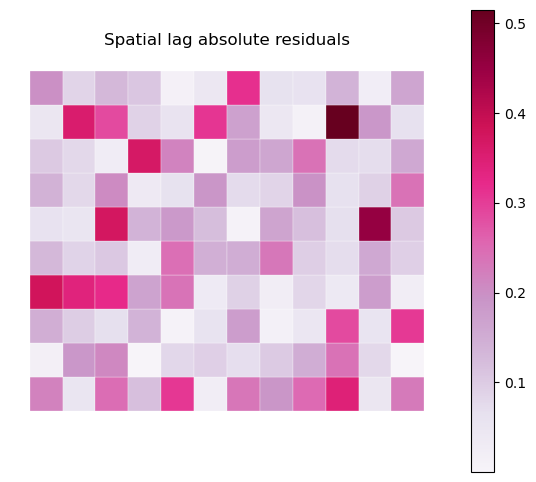

,zone_id,price,lag_prediction,lag_residual,local_cluster
105,H106,6.929,6.414,0.515,LL
70,H071,7.484,7.030,0.454,Not significant
36,H037,7.296,6.916,0.380,HL
62,H063,6.889,7.262,-0.373,Not significant
87,H088,7.098,7.466,-0.368,Not significant
97,H098,6.872,6.515,0.357,LL
9,H010,6.601,6.946,-0.345,Not significant
37,H038,6.467,6.805,-0.338,Not significant
38,H039,7.642,7.319,0.323,Not significant
114,H115,7.411,7.097,0.314,Not significant


In [12]:
gdf["lag_prediction"] = lag_model.predy.flatten()
gdf["lag_residual"] = y - gdf["lag_prediction"]
gdf["absolute_residual"] = gdf["lag_residual"].abs()
review = gdf.sort_values("absolute_residual", ascending=False)[["zone_id", "price", "lag_prediction", "lag_residual", "local_cluster"]].head(12)
fig, ax = plt.subplots(figsize=(7, 6))
gdf.plot(column="absolute_residual", cmap="PuRd", legend=True, ax=ax, edgecolor="white", linewidth=0.2)
ax.set_title("Spatial lag absolute residuals")
ax.set_axis_off()
fig.savefig(OUTPUTS / "spatial_lag_residual_outliers.png", dpi=170)
plt.show()
display(review.round(3))

In [13]:
gdf.drop(columns="geometry").to_csv(OUTPUTS / "housing_spatial_diagnostics.csv", index=False)
gdf.to_file(OUTPUTS / "housing_diagnostics.geojson", driver="GeoJSON")
print("Exported files:")
for path in sorted(OUTPUTS.iterdir()):
    print(f"- {path.name} ({path.stat().st_size} bytes)")

Exported files:
- housing_correlation_matrix.png (40782 bytes)
- housing_diagnostics.geojson (71046 bytes)
- housing_spatial_diagnostics.csv (23352 bytes)
- housing_variable_maps.png (51404 bytes)
- local_moran_price_clusters.png (16964 bytes)
- ols_residual_diagnostics.png (81003 bytes)
- spatial_lag_residual_outliers.png (24456 bytes)
- spatial_model_coefficients.png (69681 bytes)
- spatial_model_comparison.csv (225 bytes)


In [14]:
best = comparison.sort_values("aic").iloc[0]
display(Markdown(f'''## Case conclusion

The best AIC model is **{best.model}**. OLS residual Moran I is **{m_resid.I:.3f}** with simulated p-value **{m_resid.p_sim:.4f}**, so the notebook surfaces spatial dependence rather than treating the housing market as independent observations.
'''))

## Case conclusion

The best AIC model is **Spatial error**. OLS residual Moran I is **0.034** with simulated p-value **0.2050**, so the notebook surfaces spatial dependence rather than treating the housing market as independent observations.
